# Distributed and streaming estimation

EM in mixle parallelizes embarrassingly, because every accumulator obeys one contract: `value()` returns a small picklable payload of sufficient statistics, and `combine()` adds two payloads associatively. A distributed E-step is therefore: each worker accumulates statistics over its shard, the driver folds the payloads with `combine()`, ties any shared parameters once globally, and runs a single M-step. Only the (small) model travels out each iteration and only sufficient statistics come back - the encoded data never moves after setup.

Because of that contract, scaling out is a keyword argument, not a rewrite. The same `optimize` call runs in-process, across CPU cores, across a Dask or MPI cluster, or on Spark - and the same machinery also runs online, folding a stream of batches into a running estimate. This notebook walks through each, motivated by when you would reach for it.

These features live in the current mixle release.


In [1]:
import io, time
import numpy as np
import pandas as pd
from mixle.stats import GaussianDistribution, PoissonDistribution, CompositeDistribution, MixtureDistribution, GaussianEstimator, PoissonEstimator, CompositeEstimator, MixtureEstimator, seq_encode, seq_log_density_sum
from mixle.inference import seq_initialize
from mixle.inference.estimation import optimize, harmonic, constant
from mixle.inference.streaming import StreamingEstimator, IncrementalEstimator

true = MixtureDistribution([
    CompositeDistribution((GaussianDistribution(-2.0, 1.0), PoissonDistribution(3.0))),
    CompositeDistribution((GaussianDistribution(2.0, 1.0), PoissonDistribution(8.0))),
], [0.5, 0.5])
data = list(true.sampler(seed=1).sample(20000))

est = MixtureEstimator([CompositeEstimator((GaussianEstimator(), PoissonEstimator()))] * 2)

# a fixed starting model, so every backend below runs the *identical* EM and we can
# check they agree exactly rather than up to a random initialization
enc = seq_encode(data, model=true)
start = seq_initialize(enc, est, np.random.RandomState(7), p=1.0)
ll = lambda m: seq_log_density_sum(seq_encode(data, model=m), m)[1]
print('n =', len(data), '| start ll =', round(ll(start), 1))

n = 20000 | start ll = -99873.4


## One call, several process models

`optimize(..., backend=...)` selects how the work is distributed. `'local'` is the ordinary in-process path; `'mp'` shards across persistent worker processes (stdlib multiprocessing); `'dask'` uses a Dask cluster (`pip install mixle[dask]`). All run the identical algorithm - per-shard accumulation, one global fold, one M-step - so from the same fixed start they reach the same fit up to floating-point summation order.


In [2]:
fits = {}
for backend, kwargs in [('local', {}),
                        ('mp', {'num_workers': 4}),
                        ('dask', {'num_workers': 2})]:
    t0 = time.perf_counter()
    fits[backend] = optimize(data, est, prev_estimate=start, max_its=10,
                             backend=backend, out=io.StringIO(), **kwargs)
    print('%-6s ll=%.4f   %.2fs' % (backend, ll(fits[backend]), time.perf_counter() - t0))

print('all backends agree:',
      max(abs(ll(fits['local']) - ll(fits[b])) for b in ('mp', 'dask')) < 1e-6)

local  ll=-85473.9068   0.11s


mp     ll=-85473.9068   17.65s


dask   ll=-85473.9068   4.38s
all backends agree: True


The wall-clock numbers are modest here - at 20k points the per-iteration work is small relative to worker startup and the one-time shard encoding, so multiprocessing/Dask shine at larger scale or on deeper models. The point is that the fit is identical: distribution is an execution detail, not a modeling decision. MPI works the same way under an SPMD launcher (`mpiexec`), shown near the end; Spark is covered in the estimation on Spark notebook.


## DataFrames in, model out

Tabular data needs no manual unpacking: pass a pandas (or Dask, or Spark) DataFrame and a `fields=` column selection, and the encoder builds the records. One field gives scalar observations; several give tuple records matching a composite model.


In [3]:
df = pd.DataFrame({'value': [d[0] for d in data], 'count': [d[1] for d in data]})
m_df = optimize(df, est, fields=['value', 'count'], prev_estimate=start, max_its=10, out=io.StringIO())
print('dataframe fit ll=%.4f  matches local: %s' % (ll(m_df), abs(ll(m_df) - ll(fits['local'])) < 1e-6))
df.head(3)

dataframe fit ll=-85473.9068  matches local: True


,value,count
0,-2.283237,5
1,1.301899,9
2,2.153941,8


## Automatic placement: the planner

On a heterogeneous machine (some CPU cores, a GPU) you can let mixle decide the placement. `Resources.discover()` enumerates the available devices and `plan()` produces a `Placement` - how the data is sharded and which engine each shard uses - which you can print, edit, and hand back to `optimize(resources=...)`. Automation is the default, but never opaque.


In [4]:
from mixle.utils.parallel.planner import Resources, plan

resources = Resources.discover()
print('discovered devices:')
for dev in resources.devices:
    print('  ', dev.name, '| kind', dev.kind, '| engine', dev.engine, '| throughput', dev.throughput)

placement = plan(data, estimator=est, resources=resources)
print('\nplan ->', type(placement).__name__, 'with', len(placement.shards), 'shard(s)')

discovered devices:
   cpu:0 | kind cpu | engine numpy | throughput 1.0
   mps:0 | kind mps | engine torch | throughput 3.0

plan -> Placement with 2 shard(s)


## Streaming: fold a stream into a running estimate

The same combine contract supports online EM. A `StreamingEstimator` keeps a running set of sufficient statistics; each `update(batch)` decays the running stats by a step size, folds in the new batch, and re-runs the M-step. With a Robbins-Monro schedule (`harmonic(alpha)` for see-once streams, `constant(rho)` for slowly-drifting ones), this converges to the same stationary point as batch EM - but never holds more than one batch at a time. This is the tool for data that does not fit in memory, or that arrives over time.


In [5]:
stream = StreamingEstimator(
    MixtureEstimator([CompositeEstimator((GaussianEstimator(), PoissonEstimator()))] * 2),
    schedule=harmonic(0.6))

rng = np.random.RandomState(0)
curve = []
model = None
for epoch in range(10):
    for batch in np.array_split(np.array(data, dtype=object), 8):   # 8 batches per epoch
        model = stream.update(list(batch))
    curve.append(ll(model))

print('streaming final ll = %.1f   (batch EM reference %.1f)' % (curve[-1], ll(fits['local'])))

streaming final ll = -85470.8   (batch EM reference -85473.9)


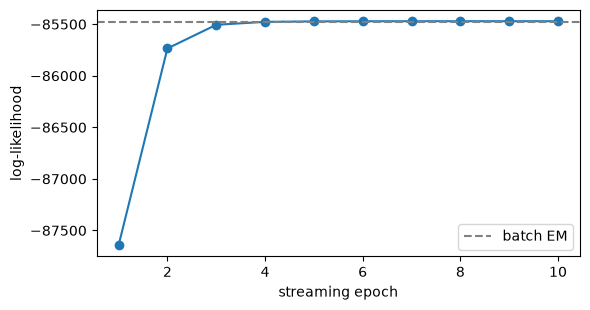

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3.2))
plt.plot(range(1, len(curve) + 1), curve, marker='o')
plt.axhline(ll(fits['local']), ls='--', color='gray', label='batch EM')
plt.xlabel('streaming epoch'); plt.ylabel('log-likelihood'); plt.legend(); plt.tight_layout(); plt.show()

## Incremental EM: revisitable chunks

`StreamingEstimator` is built for see-once streams. When the data is split into a fixed set of chunks you can revisit, `IncrementalEstimator` (Neal & Hinton's incremental EM) stores each chunk's sufficient statistics separately, and `update(chunk_id, batch)` replaces that one chunk's contribution. Re-passing the chunks converges to batch EM, and a single stale chunk can be refreshed without recomputing the rest.


incremental, 6 passes ll = -85471.0   (batch EM -85473.9)


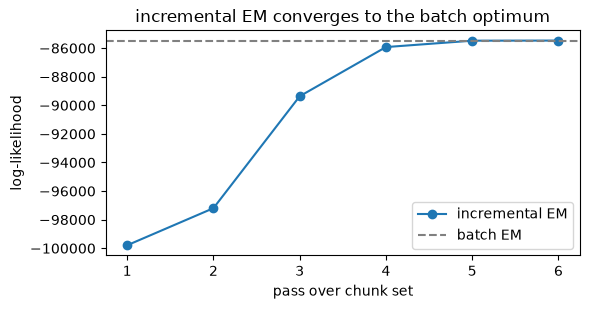

In [7]:
inc = IncrementalEstimator(
    MixtureEstimator([CompositeEstimator((GaussianEstimator(), PoissonEstimator()))] * 2),
    model=start)
chunks = [list(c) for c in np.array_split(np.array(data, dtype=object), 6)]

curve_inc = []
for _ in range(6):                              # several passes over the fixed chunk set
    for cid, chunk in enumerate(chunks):        # each update replaces that chunk's statistics
        model = inc.update(chunk, chunk_id=cid)
    curve_inc.append(ll(model))
print('incremental, 6 passes ll = %.1f   (batch EM %.1f)' % (curve_inc[-1], ll(fits['local'])))

plt.figure(figsize=(6, 3.2))
plt.plot(range(1, len(curve_inc) + 1), curve_inc, 'o-', label='incremental EM')
plt.axhline(ll(fits['local']), ls='--', color='gray', label='batch EM')
plt.xlabel('pass over chunk set'); plt.ylabel('log-likelihood')
plt.title('incremental EM converges to the batch optimum'); plt.legend()
plt.tight_layout(); plt.show()

Both online estimators are also exposed as EM strategies - `OnlineEM` and `IncrementalEM` in `mixle.utils.em` - so the same online behavior plugs straight into `optimize(strategy=...)` alongside the strategies in the fitting tutorial.


`IncrementalEstimator` is the close cousin for the epoch setting where you revisit the same chunks: instead of decaying, it remembers each chunk's contribution and replaces it on revisit (Neal-Hinton incremental EM), which converges faster when the data is finite and reusable. Both expose the same `update(...)` surface.


## MPI (SPMD)

The MPI backend runs the same script on every rank; each rank holds a shard and keeps it resident, the root folds the gathered statistics and broadcasts the updated model, so all ranks finish with the identical fit. It is launched with `mpiexec` (`pip install mixle[mpi]`).


In [8]:
script = '''
import numpy as np
from mixle.stats import GaussianDistribution, PoissonDistribution, CompositeDistribution, MixtureDistribution, GaussianEstimator, PoissonEstimator, CompositeEstimator, MixtureEstimator, seq_encode
from mixle.inference import seq_initialize
from mixle.inference.estimation import optimize
from mixle.utils.parallel.mpi import MPIEncodedData, mpi_out
from mpi4py import MPI

true = MixtureDistribution([
    CompositeDistribution((GaussianDistribution(-2.0, 1.0), PoissonDistribution(3.0))),
    CompositeDistribution((GaussianDistribution(2.0, 1.0), PoissonDistribution(8.0)))], [0.5, 0.5])
data = true.sampler(seed=1).sample(20000)
est = MixtureEstimator([CompositeEstimator((GaussianEstimator(), PoissonEstimator()))] * 2)
start = seq_initialize(seq_encode(data, model=true), est, np.random.RandomState(7), p=1.0)

enc = MPIEncodedData(data, estimator=est)                 # every rank holds data[rank::size]
model = optimize(None, est, enc_data=enc, prev_estimate=start, max_its=10, out=mpi_out())
if MPI.COMM_WORLD.Get_rank() == 0:
    print('fitted means:', sorted(round(c.dists[0].mu, 3) for c in model.components))
'''
import os, shutil, subprocess, sys
with open('mpi_demo.py', 'w') as f:
    f.write(script)
mpiexec = shutil.which('mpiexec') or shutil.which('mpirun')
try:
    import mpi4py
    have_mpi = mpiexec is not None
except ImportError:
    have_mpi = False
if have_mpi:
    env = dict(os.environ, PYTHONPATH=os.pathsep.join(sys.path))
    res = subprocess.run([mpiexec, '-n', '2', sys.executable, 'mpi_demo.py'],
                         capture_output=True, text=True, timeout=600, env=env)
    print(res.stdout.strip() or res.stderr[-600:])
else:
    print('mpi4py / mpiexec not available - install with: pip install mixle[mpi]')
os.remove('mpi_demo.py')

Iteration 1: ln[p_mat(Data|Model)]=-9.987178e+04, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=1.603028e+00
Iteration 2: ln[p_mat(Data|Model)]=-9.986059e+04, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=1.118617e+01
Iteration 3: ln[p_mat(Data|Model)]=-9.978247e+04, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=7.812016e+01
Iteration 4: ln[p_mat(Data|Model)]=-9.926778e+04, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=5.146946e+02
Iteration 5: ln[p_mat(Data|Model)]=-9.675252e+04, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=2.515255e+03
Iteration 6: ln[p_mat(Data|Model)]=-9.155078e+04, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=5.201745e+03
Iteration 7: ln[p_mat(Data|Model)]=-8.786636e+04, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=3.684413e+03
Iteration 8: ln[p_mat(Data|Model)]=-8.600027e+04, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=1.866096e+03
Iteration 9: ln[p_mat(Data|Model)]=-8.551378e+04, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=4.864830e+02
I

## Choosing a backend

| backend | process model | data residency | reach for it when |
|---|---|---|---|
| `local` | in-process | driver memory | the default; small/medium data |
| `mp` (`MPEncodedData`) | persistent worker processes | encoded shard per worker | one big multicore machine |
| `dask` (`DaskEncodedData`) | Dask cluster | encoded per partition | a cluster you already run on Dask |
| `mpi` (`MPIEncodedData`) | SPMD ranks (`mpiexec`) | encoded shard per rank | HPC / multi-node |
| Spark RDD | cluster executors | encoded per partition | existing Spark data and infrastructure |
| `StreamingEstimator` | online, one batch at a time | running statistics only | see-once streams; data that does not fit in memory |
| `IncrementalEstimator` | online, revisitable chunks | per-chunk statistics | a fixed chunk set you re-pass or refresh incrementally |

Every one runs the identical statistical algorithm - per-shard accumulation, one global fold with parameter tying, one M-step - so results are interchangeable up to floating-point summation order. The compute engine (numpy/numba/torch - see compute engines) composes underneath any of them.
